# Lightweight ML Classifier: Logistic Regression for Silicon Labs EFR32 (Multi-Target Training)

This notebook trains and evaluates a **Logistic Regression Classifier** separately for all 3 critical intraoperative clinical targets:
1. **`Future_Hypotension`** (Mean Arterial Pressure < 65 mmHg)
2. **`Future_Hypoxia`** (Peripheral Oxygen Saturation $\text{SpO}_2$ < 90%)
3. **`Future_Tachycardia`** (Heart Rate > 100 bpm)

### Features:
- **Same Predictors as 02_model**: Uses HR, SBP, DBP, MBP, SpO2, RR_CO2, ETCO2, FiO2, and Body Temperature.
- **Relative File Paths**: Loads data using relative path `../patient_labeled_data`.
- **Full Metrics Suite**: Evaluates AUROC, AUPRC, Accuracy, Balanced Accuracy, Sensitivity, Specificity, Precision, F1-Score, MCC, and Confusion Matrix.
- **Silicon Labs EFR32 MCU C Code Generation**: Exports C header file for embedded deployment.


In [8]:
import os
import gc
import glob
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    classification_report,
    ConfusionMatrixDisplay
)
import joblib

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print("Scikit-Learn ML Environment Loaded Successfully.")

Scikit-Learn ML Environment Loaded Successfully.


In [9]:
# ======================================================
# Load Patient Files (Relative Paths) & Feature Extraction
# ======================================================

# RELATIVE PATH to patient raw/labeled dataset
input_dir = os.path.join("..", "patient_labeled_data")

csv_files = sorted(glob.glob(os.path.join(input_dir, "patient_*_1hz.csv")))

# Same 9 vital sign predictors used in 02_model
features = [
    "Solar8000/HR",
    "Solar8000/ART_SBP",
    "Solar8000/ART_DBP",
    "Solar8000/ART_MBP",
    "Solar8000/PLETH_SPO2",
    "Solar8000/RR_CO2",
    "Solar8000/ETCO2",
    "Primus/FIO2",
    "Solar8000/BT"
]

train_val_files, test_files = train_test_split(csv_files, test_size=0.20, random_state=42, shuffle=True)
train_files, val_files = train_test_split(train_val_files, test_size=0.125, random_state=42, shuffle=True)

print(f"Dataset Path : {input_dir}")
print(f"Total Patients: {len(csv_files)} | Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}")

def extract_window_features(arr_window):
    means = np.mean(arr_window, axis=0)
    stds = np.std(arr_window, axis=0)
    mins = np.min(arr_window, axis=0)
    maxs = np.max(arr_window, axis=0)
    slopes = (arr_window[-1] - arr_window[0]) / (len(arr_window) + 1e-5)
    return np.hstack([means, stds, mins, maxs, slopes]).astype(np.float32)

feature_names = [f"{feat}_{stat}" for stat in ["mean", "std", "min", "max", "slope"] for feat in [f.split("/")[-1] for f in features]]

WINDOW_SIZE = 600
STRIDE = 100

def build_dataset_matrix(file_list, target_col, oversample_factor=3):
    X_list, y_list = [], []
    for file in file_list:
        try:
            df = pd.read_csv(file, usecols=features + [target_col], dtype=np.float32).ffill().fillna(0)
            arr = df[features].values
            y_vals = df[target_col].values.astype(np.float32)
            
            for i in range(0, len(arr) - WINDOW_SIZE, STRIDE):
                feat_vec = extract_window_features(arr[i:i + WINDOW_SIZE])
                label = y_vals[i + WINDOW_SIZE]
                
                X_list.append(feat_vec)
                y_list.append(label)
                
                if label == 1.0 and oversample_factor > 1:
                    for _ in range(oversample_factor - 1):
                        X_list.append(feat_vec)
                        y_list.append(label)
        except Exception:
            continue
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)

def get_optimal_tau(y_t, y_p):
    best_tau, best_f1 = 0.5, -1.0
    for tau in np.linspace(0.01, 0.99, 99):
        f1 = f1_score(y_t, (y_p >= tau).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_tau = f1, tau
    return best_tau

def compute_metrics(y_t, y_p, tau):
    y_b = (y_p >= tau).astype(int)
    auroc = roc_auc_score(y_t, y_p)
    auprc = average_precision_score(y_t, y_p)
    acc = accuracy_score(y_t, y_b)
    bal_acc = balanced_accuracy_score(y_t, y_b)
    prec = precision_score(y_t, y_b, zero_division=0)
    rec = recall_score(y_t, y_b, zero_division=0)
    f1 = f1_score(y_t, y_b, zero_division=0)
    mcc = matthews_corrcoef(y_t, y_b)
    tn, fp, fn, tp = confusion_matrix(y_t, y_b).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    return dict(auroc=auroc, auprc=auprc, acc=acc, bal_acc=bal_acc, prec=prec, rec=rec, spec=spec, f1=f1, mcc=mcc, tn=tn, fp=fp, fn=fn, tp=tp)

Dataset Path : ../patient_labeled_data
Total Patients: 3764 | Train: 2634 | Val: 377 | Test: 753


 TRAINING LOGISTIC REGRESSION FOR TARGET: Future_Hypotension
Saved trained model to relative path: ./efr32_lr_Future_Hypotension.joblib
Optimal Decision Threshold (tau*) on Val Set: 0.4100

     LOGISTIC REGRESSION COMPREHENSIVE TEST METRICS: Future_Hypotension
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.41)
---------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.7143                  0.7143
AUPRC (PR AUC)          : 0.4671                  0.4671
Accuracy                : 0.6907                  0.6256
Balanced Accuracy       : 0.6608                  0.6677
Sensitivity / Recall    : 0.5910                  0.7661
Specificity (TNR)       : 0.7307                  0.5693
Precision (PPV)         : 0.4681                  0.4163
F1 Score                : 0.5224                  0.5395
MCC                     : 0.3026                  0.3037
---------------------------------------------------------------------------
Confu

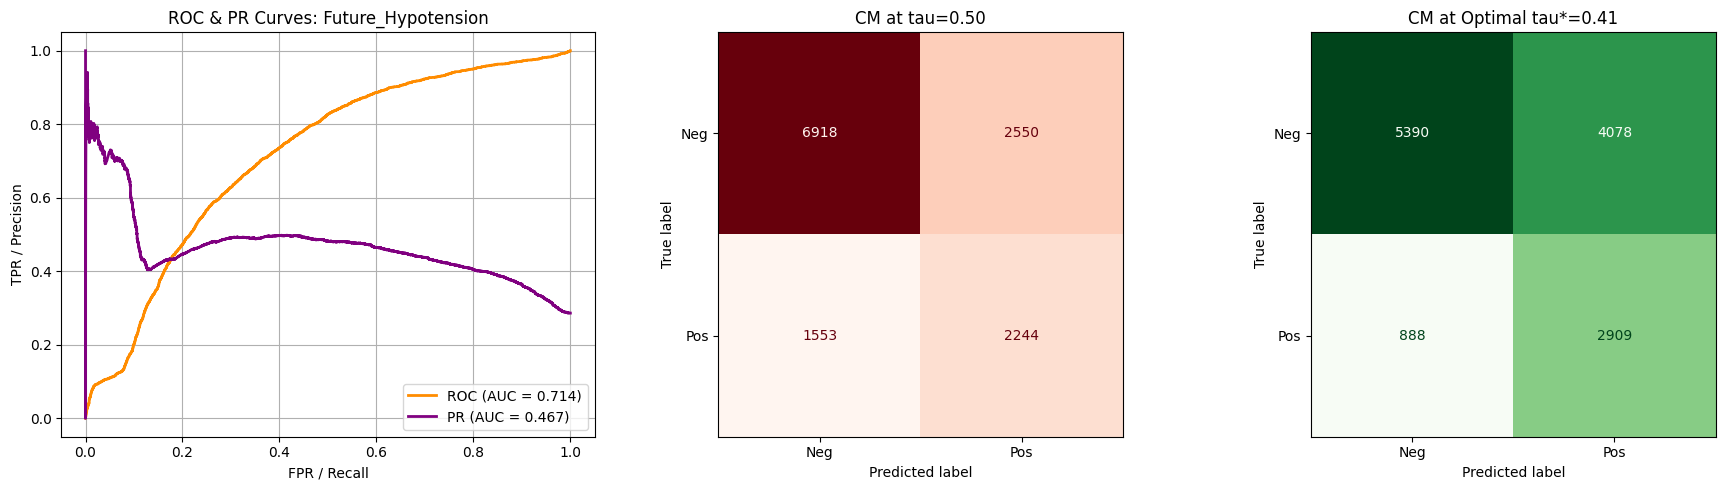

In [10]:
# ======================================================
# Training & Evaluation Pipeline for Target: Future_Hypotension
# ======================================================

target_Future_Hypotension = "Future_Hypotension"
print("=" * 75)
print(f" TRAINING LOGISTIC REGRESSION FOR TARGET: {target_Future_Hypotension}")
print("=" * 75)

X_tr, y_tr = build_dataset_matrix(train_files[:300], target_Future_Hypotension, oversample_factor=3)
X_va, y_va = build_dataset_matrix(val_files[:50], target_Future_Hypotension, oversample_factor=1)
X_te, y_te = build_dataset_matrix(test_files[:100], target_Future_Hypotension, oversample_factor=1)

scaler_Future_Hypotension = StandardScaler()
X_tr_sc = scaler_Future_Hypotension.fit_transform(X_tr)
X_va_sc = scaler_Future_Hypotension.transform(X_va)
X_te_sc = scaler_Future_Hypotension.transform(X_te)

clf_Future_Hypotension = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', solver='liblinear', random_state=42)
clf_Future_Hypotension.fit(X_tr_sc, y_tr)

model_save_path = os.path.join(".", f"efr32_lr_{target_Future_Hypotension}.joblib")
joblib.dump(clf_Future_Hypotension, model_save_path)
print(f"Saved trained model to relative path: {model_save_path}")

val_probs = clf_Future_Hypotension.predict_proba(X_va_sc)[:, 1]
optimal_tau_Future_Hypotension = get_optimal_tau(y_va, val_probs)
print(f"Optimal Decision Threshold (tau*) on Val Set: {optimal_tau_Future_Hypotension:.4f}")

test_probs = clf_Future_Hypotension.predict_proba(X_te_sc)[:, 1]
m_def = compute_metrics(y_te, test_probs, 0.50)
m_opt = compute_metrics(y_te, test_probs, optimal_tau_Future_Hypotension)

print("\n" + "=" * 75)
print(f"     LOGISTIC REGRESSION COMPREHENSIVE TEST METRICS: {target_Future_Hypotension}")
print("=" * 75)
print(f"Metric                 Default (tau=0.50)       OPTIMAL (tau*={optimal_tau_Future_Hypotension:.2f})")
print("-" * 75)
print(f"AUROC (ROC AUC)         : {m_def['auroc']:.4f}                  {m_opt['auroc']:.4f}")
print(f"AUPRC (PR AUC)          : {m_def['auprc']:.4f}                  {m_opt['auprc']:.4f}")
print(f"Accuracy                : {m_def['acc']:.4f}                  {m_opt['acc']:.4f}")
print(f"Balanced Accuracy       : {m_def['bal_acc']:.4f}                  {m_opt['bal_acc']:.4f}")
print(f"Sensitivity / Recall    : {m_def['rec']:.4f}                  {m_opt['rec']:.4f}")
print(f"Specificity (TNR)       : {m_def['spec']:.4f}                  {m_opt['spec']:.4f}")
print(f"Precision (PPV)         : {m_def['prec']:.4f}                  {m_opt['prec']:.4f}")
print(f"F1 Score                : {m_def['f1']:.4f}                  {m_opt['f1']:.4f}")
print(f"MCC                     : {m_def['mcc']:.4f}                  {m_opt['mcc']:.4f}")
print("-" * 75)
print(f"Confusion Matrix (0.50) : TN={m_def['tn']}, FP={m_def['fp']}, FN={m_def['fn']}, TP={m_def['tp']}")
print(f"Confusion Matrix (tau*) : TN={m_opt['tn']}, FP={m_opt['fp']}, FN={m_opt['fn']}, TP={m_opt['tp']}")
print("=" * 75)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_te, test_probs)
prec_pts, rec_pts, _ = precision_recall_curve(y_te, test_probs)
axes[0].plot(fpr, tpr, label=f"ROC (AUC = {m_opt['auroc']:.3f})", color="darkorange", lw=2)
axes[0].plot(rec_pts, prec_pts, label=f"PR (AUC = {m_opt['auprc']:.3f})", color="purple", lw=2)
axes[0].set_title(f"ROC & PR Curves: {target_Future_Hypotension}")
axes[0].set_xlabel("FPR / Recall")
axes[0].set_ylabel("TPR / Precision")
axes[0].legend()
axes[0].grid(True)

cm_d1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= 0.50).astype(int)), display_labels=["Neg", "Pos"])
cm_d1.plot(ax=axes[1], cmap="Reds", colorbar=False)
axes[1].set_title("CM at tau=0.50")

cm_d2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= optimal_tau_Future_Hypotension).astype(int)), display_labels=["Neg", "Pos"])
cm_d2.plot(ax=axes[2], cmap="Greens", colorbar=False)
axes[2].set_title(f"CM at Optimal tau*={optimal_tau_Future_Hypotension:.2f}")

plt.tight_layout()
plt.show()

 TRAINING LOGISTIC REGRESSION FOR TARGET: Future_Hypoxia
Saved trained model to relative path: ./efr32_lr_Future_Hypoxia.joblib
Optimal Decision Threshold (tau*) on Val Set: 0.9000

     LOGISTIC REGRESSION COMPREHENSIVE TEST METRICS: Future_Hypoxia
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.90)
---------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.8725                  0.8725
AUPRC (PR AUC)          : 0.4027                  0.4027
Accuracy                : 0.8782                  0.9475
Balanced Accuracy       : 0.8180                  0.7071
Sensitivity / Recall    : 0.7516                  0.4415
Specificity (TNR)       : 0.8845                  0.9728
Precision (PPV)         : 0.2456                  0.4478
F1 Score                : 0.3702                  0.4446
MCC                     : 0.3839                  0.4171
---------------------------------------------------------------------------
Confusion Matrix 

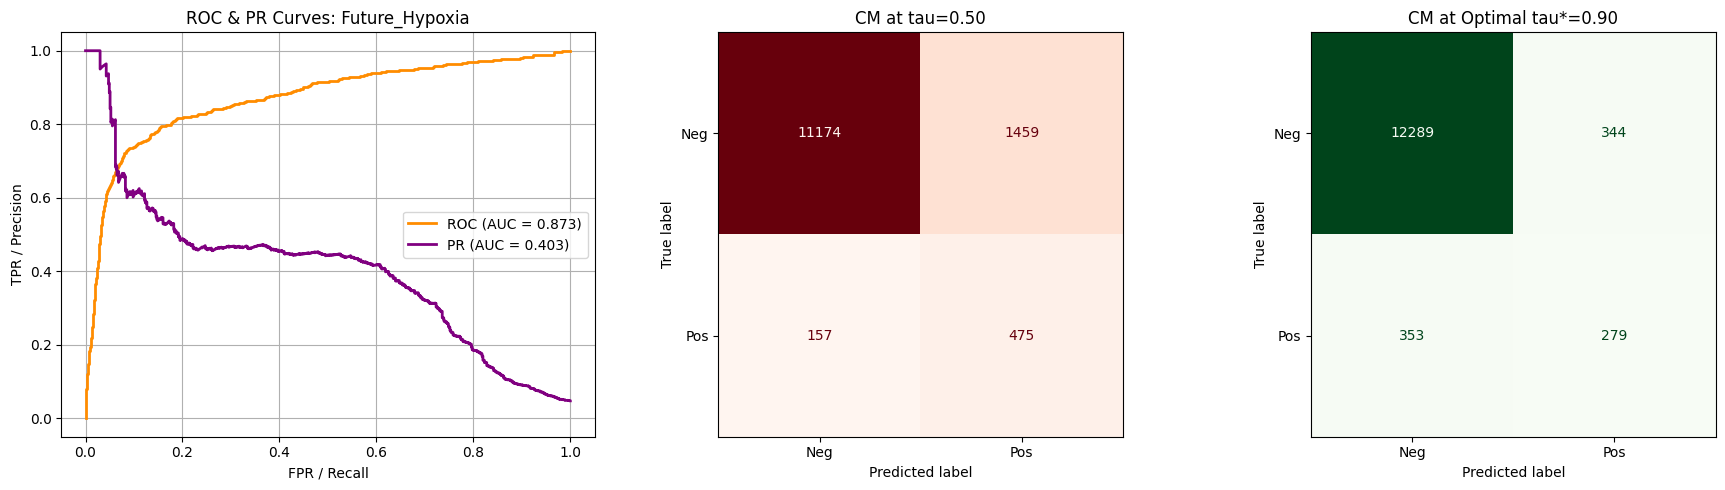

In [11]:
# ======================================================
# Training & Evaluation Pipeline for Target: Future_Hypoxia
# ======================================================

target_Future_Hypoxia = "Future_Hypoxia"
print("=" * 75)
print(f" TRAINING LOGISTIC REGRESSION FOR TARGET: {target_Future_Hypoxia}")
print("=" * 75)

X_tr, y_tr = build_dataset_matrix(train_files[:300], target_Future_Hypoxia, oversample_factor=3)
X_va, y_va = build_dataset_matrix(val_files[:50], target_Future_Hypoxia, oversample_factor=1)
X_te, y_te = build_dataset_matrix(test_files[:100], target_Future_Hypoxia, oversample_factor=1)

scaler_Future_Hypoxia = StandardScaler()
X_tr_sc = scaler_Future_Hypoxia.fit_transform(X_tr)
X_va_sc = scaler_Future_Hypoxia.transform(X_va)
X_te_sc = scaler_Future_Hypoxia.transform(X_te)

clf_Future_Hypoxia = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', solver='liblinear', random_state=42)
clf_Future_Hypoxia.fit(X_tr_sc, y_tr)

model_save_path = os.path.join(".", f"efr32_lr_{target_Future_Hypoxia}.joblib")
joblib.dump(clf_Future_Hypoxia, model_save_path)
print(f"Saved trained model to relative path: {model_save_path}")

val_probs = clf_Future_Hypoxia.predict_proba(X_va_sc)[:, 1]
optimal_tau_Future_Hypoxia = get_optimal_tau(y_va, val_probs)
print(f"Optimal Decision Threshold (tau*) on Val Set: {optimal_tau_Future_Hypoxia:.4f}")

test_probs = clf_Future_Hypoxia.predict_proba(X_te_sc)[:, 1]
m_def = compute_metrics(y_te, test_probs, 0.50)
m_opt = compute_metrics(y_te, test_probs, optimal_tau_Future_Hypoxia)

print("\n" + "=" * 75)
print(f"     LOGISTIC REGRESSION COMPREHENSIVE TEST METRICS: {target_Future_Hypoxia}")
print("=" * 75)
print(f"Metric                 Default (tau=0.50)       OPTIMAL (tau*={optimal_tau_Future_Hypoxia:.2f})")
print("-" * 75)
print(f"AUROC (ROC AUC)         : {m_def['auroc']:.4f}                  {m_opt['auroc']:.4f}")
print(f"AUPRC (PR AUC)          : {m_def['auprc']:.4f}                  {m_opt['auprc']:.4f}")
print(f"Accuracy                : {m_def['acc']:.4f}                  {m_opt['acc']:.4f}")
print(f"Balanced Accuracy       : {m_def['bal_acc']:.4f}                  {m_opt['bal_acc']:.4f}")
print(f"Sensitivity / Recall    : {m_def['rec']:.4f}                  {m_opt['rec']:.4f}")
print(f"Specificity (TNR)       : {m_def['spec']:.4f}                  {m_opt['spec']:.4f}")
print(f"Precision (PPV)         : {m_def['prec']:.4f}                  {m_opt['prec']:.4f}")
print(f"F1 Score                : {m_def['f1']:.4f}                  {m_opt['f1']:.4f}")
print(f"MCC                     : {m_def['mcc']:.4f}                  {m_opt['mcc']:.4f}")
print("-" * 75)
print(f"Confusion Matrix (0.50) : TN={m_def['tn']}, FP={m_def['fp']}, FN={m_def['fn']}, TP={m_def['tp']}")
print(f"Confusion Matrix (tau*) : TN={m_opt['tn']}, FP={m_opt['fp']}, FN={m_opt['fn']}, TP={m_opt['tp']}")
print("=" * 75)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_te, test_probs)
prec_pts, rec_pts, _ = precision_recall_curve(y_te, test_probs)
axes[0].plot(fpr, tpr, label=f"ROC (AUC = {m_opt['auroc']:.3f})", color="darkorange", lw=2)
axes[0].plot(rec_pts, prec_pts, label=f"PR (AUC = {m_opt['auprc']:.3f})", color="purple", lw=2)
axes[0].set_title(f"ROC & PR Curves: {target_Future_Hypoxia}")
axes[0].set_xlabel("FPR / Recall")
axes[0].set_ylabel("TPR / Precision")
axes[0].legend()
axes[0].grid(True)

cm_d1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= 0.50).astype(int)), display_labels=["Neg", "Pos"])
cm_d1.plot(ax=axes[1], cmap="Reds", colorbar=False)
axes[1].set_title("CM at tau=0.50")

cm_d2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= optimal_tau_Future_Hypoxia).astype(int)), display_labels=["Neg", "Pos"])
cm_d2.plot(ax=axes[2], cmap="Greens", colorbar=False)
axes[2].set_title(f"CM at Optimal tau*={optimal_tau_Future_Hypoxia:.2f}")

plt.tight_layout()
plt.show()

 TRAINING LOGISTIC REGRESSION FOR TARGET: Future_Tachycardia
Saved trained model to relative path: ./efr32_lr_Future_Tachycardia.joblib
Optimal Decision Threshold (tau*) on Val Set: 0.7300

     LOGISTIC REGRESSION COMPREHENSIVE TEST METRICS: Future_Tachycardia
Metric                 Default (tau=0.50)       OPTIMAL (tau*=0.73)
---------------------------------------------------------------------------
AUROC (ROC AUC)         : 0.9065                  0.9065
AUPRC (PR AUC)          : 0.7044                  0.7044
Accuracy                : 0.8348                  0.9133
Balanced Accuracy       : 0.8249                  0.8083
Sensitivity / Recall    : 0.8123                  0.6732
Specificity (TNR)       : 0.8376                  0.9435
Precision (PPV)         : 0.3859                  0.5995
F1 Score                : 0.5233                  0.6342
MCC                     : 0.4827                  0.5865
---------------------------------------------------------------------------
Confu

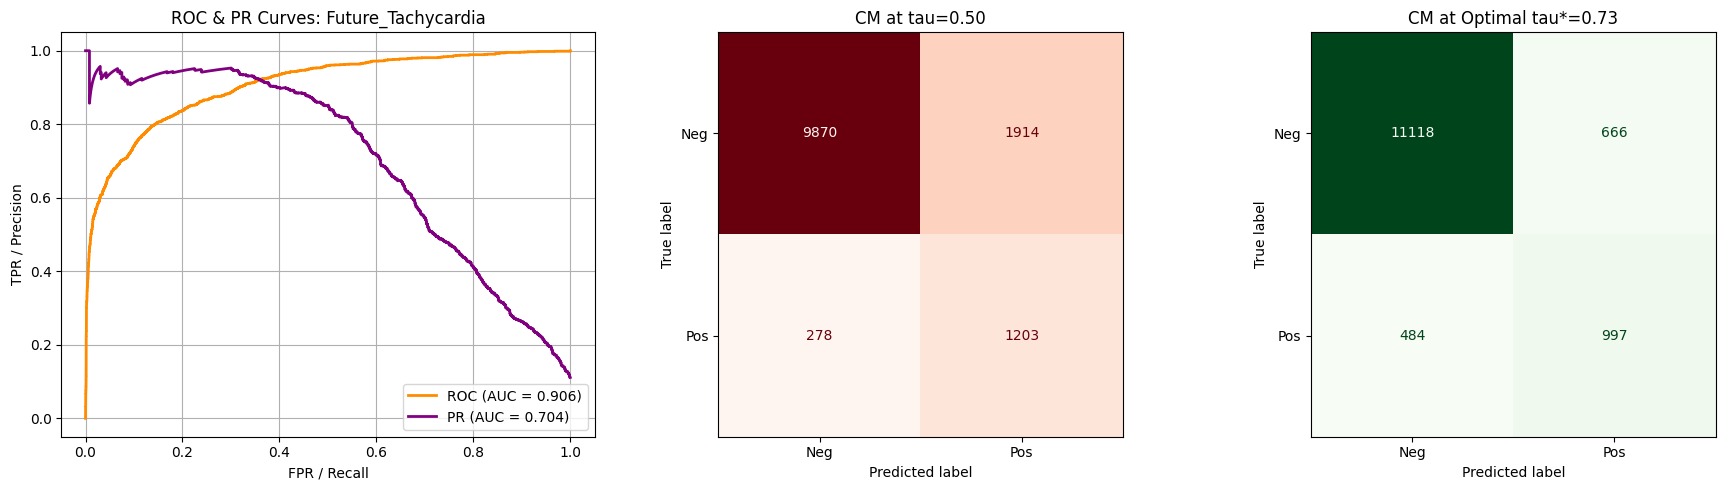

In [12]:
# ======================================================
# Training & Evaluation Pipeline for Target: Future_Tachycardia
# ======================================================

target_Future_Tachycardia = "Future_Tachycardia"
print("=" * 75)
print(f" TRAINING LOGISTIC REGRESSION FOR TARGET: {target_Future_Tachycardia}")
print("=" * 75)

X_tr, y_tr = build_dataset_matrix(train_files[:300], target_Future_Tachycardia, oversample_factor=3)
X_va, y_va = build_dataset_matrix(val_files[:50], target_Future_Tachycardia, oversample_factor=1)
X_te, y_te = build_dataset_matrix(test_files[:100], target_Future_Tachycardia, oversample_factor=1)

scaler_Future_Tachycardia = StandardScaler()
X_tr_sc = scaler_Future_Tachycardia.fit_transform(X_tr)
X_va_sc = scaler_Future_Tachycardia.transform(X_va)
X_te_sc = scaler_Future_Tachycardia.transform(X_te)

clf_Future_Tachycardia = LogisticRegression(C=1.0, penalty='l2', class_weight='balanced', solver='liblinear', random_state=42)
clf_Future_Tachycardia.fit(X_tr_sc, y_tr)

model_save_path = os.path.join(".", f"efr32_lr_{target_Future_Tachycardia}.joblib")
joblib.dump(clf_Future_Tachycardia, model_save_path)
print(f"Saved trained model to relative path: {model_save_path}")

val_probs = clf_Future_Tachycardia.predict_proba(X_va_sc)[:, 1]
optimal_tau_Future_Tachycardia = get_optimal_tau(y_va, val_probs)
print(f"Optimal Decision Threshold (tau*) on Val Set: {optimal_tau_Future_Tachycardia:.4f}")

test_probs = clf_Future_Tachycardia.predict_proba(X_te_sc)[:, 1]
m_def = compute_metrics(y_te, test_probs, 0.50)
m_opt = compute_metrics(y_te, test_probs, optimal_tau_Future_Tachycardia)

print("\n" + "=" * 75)
print(f"     LOGISTIC REGRESSION COMPREHENSIVE TEST METRICS: {target_Future_Tachycardia}")
print("=" * 75)
print(f"Metric                 Default (tau=0.50)       OPTIMAL (tau*={optimal_tau_Future_Tachycardia:.2f})")
print("-" * 75)
print(f"AUROC (ROC AUC)         : {m_def['auroc']:.4f}                  {m_opt['auroc']:.4f}")
print(f"AUPRC (PR AUC)          : {m_def['auprc']:.4f}                  {m_opt['auprc']:.4f}")
print(f"Accuracy                : {m_def['acc']:.4f}                  {m_opt['acc']:.4f}")
print(f"Balanced Accuracy       : {m_def['bal_acc']:.4f}                  {m_opt['bal_acc']:.4f}")
print(f"Sensitivity / Recall    : {m_def['rec']:.4f}                  {m_opt['rec']:.4f}")
print(f"Specificity (TNR)       : {m_def['spec']:.4f}                  {m_opt['spec']:.4f}")
print(f"Precision (PPV)         : {m_def['prec']:.4f}                  {m_opt['prec']:.4f}")
print(f"F1 Score                : {m_def['f1']:.4f}                  {m_opt['f1']:.4f}")
print(f"MCC                     : {m_def['mcc']:.4f}                  {m_opt['mcc']:.4f}")
print("-" * 75)
print(f"Confusion Matrix (0.50) : TN={m_def['tn']}, FP={m_def['fp']}, FN={m_def['fn']}, TP={m_def['tp']}")
print(f"Confusion Matrix (tau*) : TN={m_opt['tn']}, FP={m_opt['fp']}, FN={m_opt['fn']}, TP={m_opt['tp']}")
print("=" * 75)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fpr, tpr, _ = roc_curve(y_te, test_probs)
prec_pts, rec_pts, _ = precision_recall_curve(y_te, test_probs)
axes[0].plot(fpr, tpr, label=f"ROC (AUC = {m_opt['auroc']:.3f})", color="darkorange", lw=2)
axes[0].plot(rec_pts, prec_pts, label=f"PR (AUC = {m_opt['auprc']:.3f})", color="purple", lw=2)
axes[0].set_title(f"ROC & PR Curves: {target_Future_Tachycardia}")
axes[0].set_xlabel("FPR / Recall")
axes[0].set_ylabel("TPR / Precision")
axes[0].legend()
axes[0].grid(True)

cm_d1 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= 0.50).astype(int)), display_labels=["Neg", "Pos"])
cm_d1.plot(ax=axes[1], cmap="Reds", colorbar=False)
axes[1].set_title("CM at tau=0.50")

cm_d2 = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_te, (test_probs >= optimal_tau_Future_Tachycardia).astype(int)), display_labels=["Neg", "Pos"])
cm_d2.plot(ax=axes[2], cmap="Greens", colorbar=False)
axes[2].set_title(f"CM at Optimal tau*={optimal_tau_Future_Tachycardia:.2f}")

plt.tight_layout()
plt.show()

In [13]:
# ======================================================
# Export C Code Weights & Sigmoid Code for EFR32 Microcontroller
# ======================================================

print("=" * 70)
print(" EXPORTING LOGISTIC REGRESSION C ARRAYS FOR SILICON LABS EFR32")
print("=" * 70)

weights = clf_Future_Tachycardia.coef_[0]
bias = clf_Future_Tachycardia.intercept_[0]

c_code = "// Silicon Labs EFR32 Microcontroller Logistic Regression Weights\n"
c_code += f"// Input vector length: {len(weights)} features\n"
c_code += "#include <math.h>\n#include <stdbool.h>\n\n"
c_code += f"const float g_lr_bias = {bias:.6f}f;\n"
c_code += "const float g_lr_weights[] = {\n    "
c_code += ", ".join([f"{w:.6f}f" for w in weights])
c_code += "\n};\n\n"

c_code += "float sigmoid(float z) {\n"
c_code += "    return 1.0f / (1.0f + expf(-z));\n"
c_code += "}\n\n"
c_code += "bool predict_clinical_event_lr(const float* features, float threshold) {\n"
c_code += "    float z = g_lr_bias;\n"
c_code += "    for (int i = 0; i < 45; i++) {\n"
c_code += "        z += g_lr_weights[i] * features[i];\n"
c_code += "    }\n"
c_code += "    return sigmoid(z) >= threshold;\n"
c_code += "}\n"

c_header_path = os.path.join(".", "efr32_logistic_regression.h")
with open(c_header_path, "w") as f:
    f.write(c_code)

print(f"Saved C Header Code to relative path: {c_header_path}")
print("Sample C Code:")
print(c_code[:350] + "...")

 EXPORTING LOGISTIC REGRESSION C ARRAYS FOR SILICON LABS EFR32
Saved C Header Code to relative path: ./efr32_logistic_regression.h
Sample C Code:
// Silicon Labs EFR32 Microcontroller Logistic Regression Weights
// Input vector length: 45 features
#include <math.h>
#include <stdbool.h>

const float g_lr_bias = -0.612443f;
const float g_lr_weights[] = {
    0.935700f, -0.186649f, 0.207227f, -0.018306f, 0.037011f, -0.234613f, 0.097071f, 0.028787f, 0.201942f, 0.282032f, -0.049303f, -0.252570f, ...
